In [19]:
import sys
sys.path.append("../src")

import GOenrichment as ge
import importlib

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv",
}



In [18]:
print("shared_genes:", len(shared_genes))
print("unique transcriptome genes:", len(set(df["gene_name"].str.upper())))
print("Exactly equal?", shared_genes == set(df["gene_name"].str.upper()))

shared_genes: 10074
unique transcriptome genes: 10074
Exactly equal? True



Proneural
Significant genes after filtering: 3417
Proneural: BP
Proneural: CC
Proneural: MF


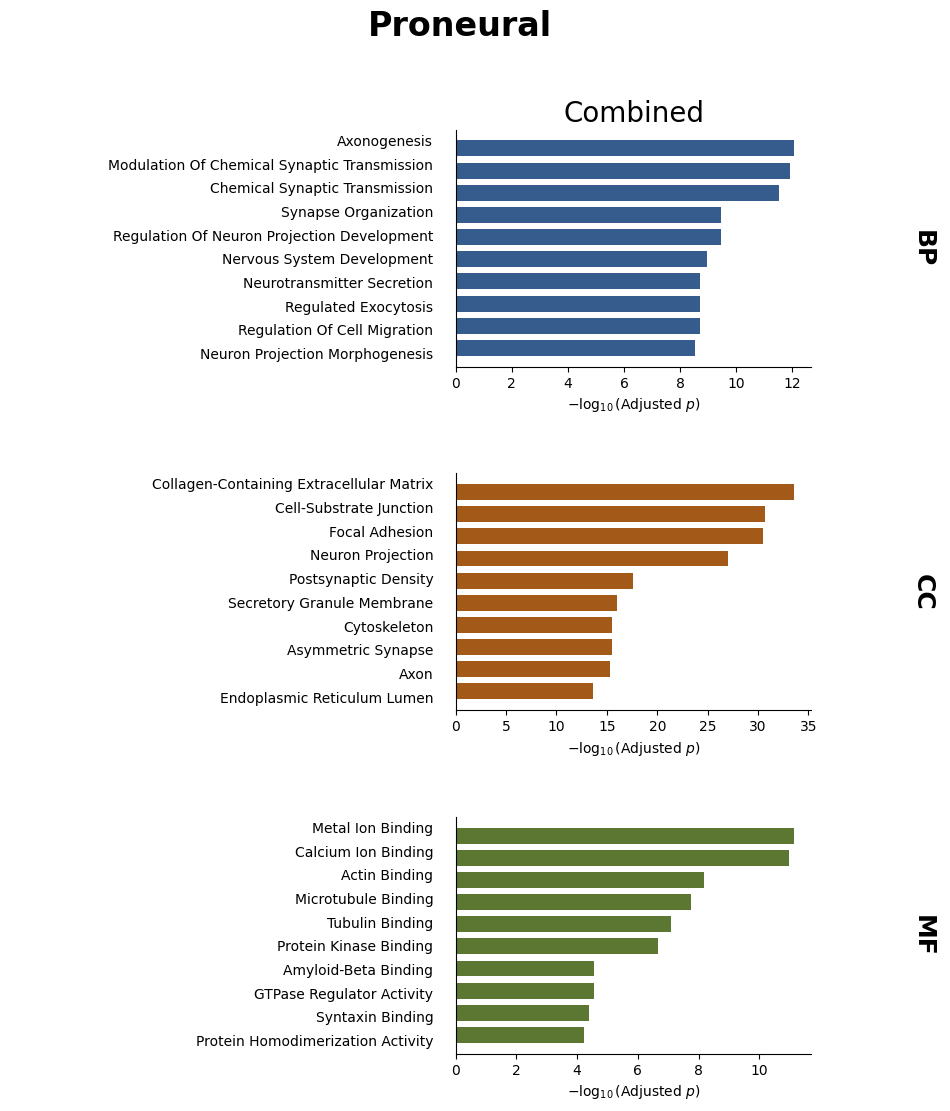


Classical
Significant genes after filtering: 3767
Classical: BP
Classical: CC
Classical: MF


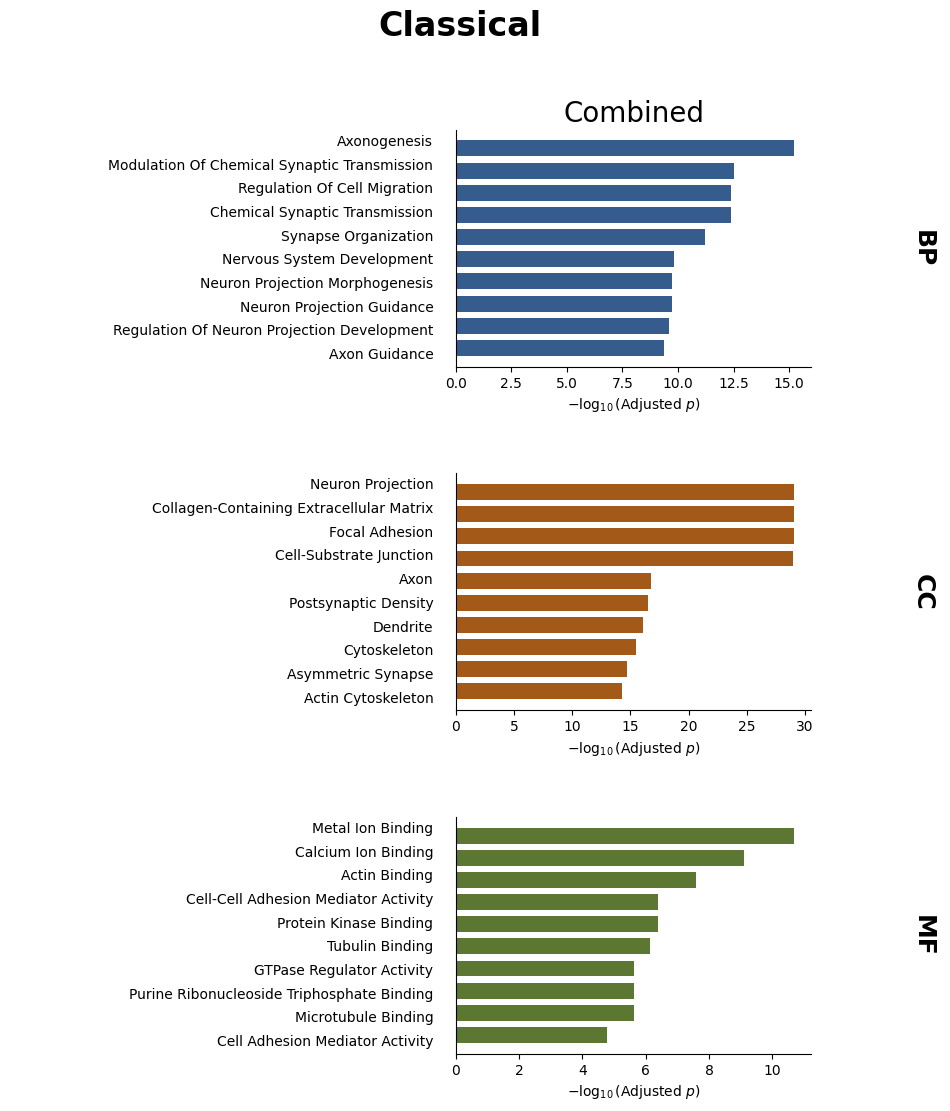


Mesenchymal
Significant genes after filtering: 4071
Mesenchymal: BP
Mesenchymal: CC
Mesenchymal: MF


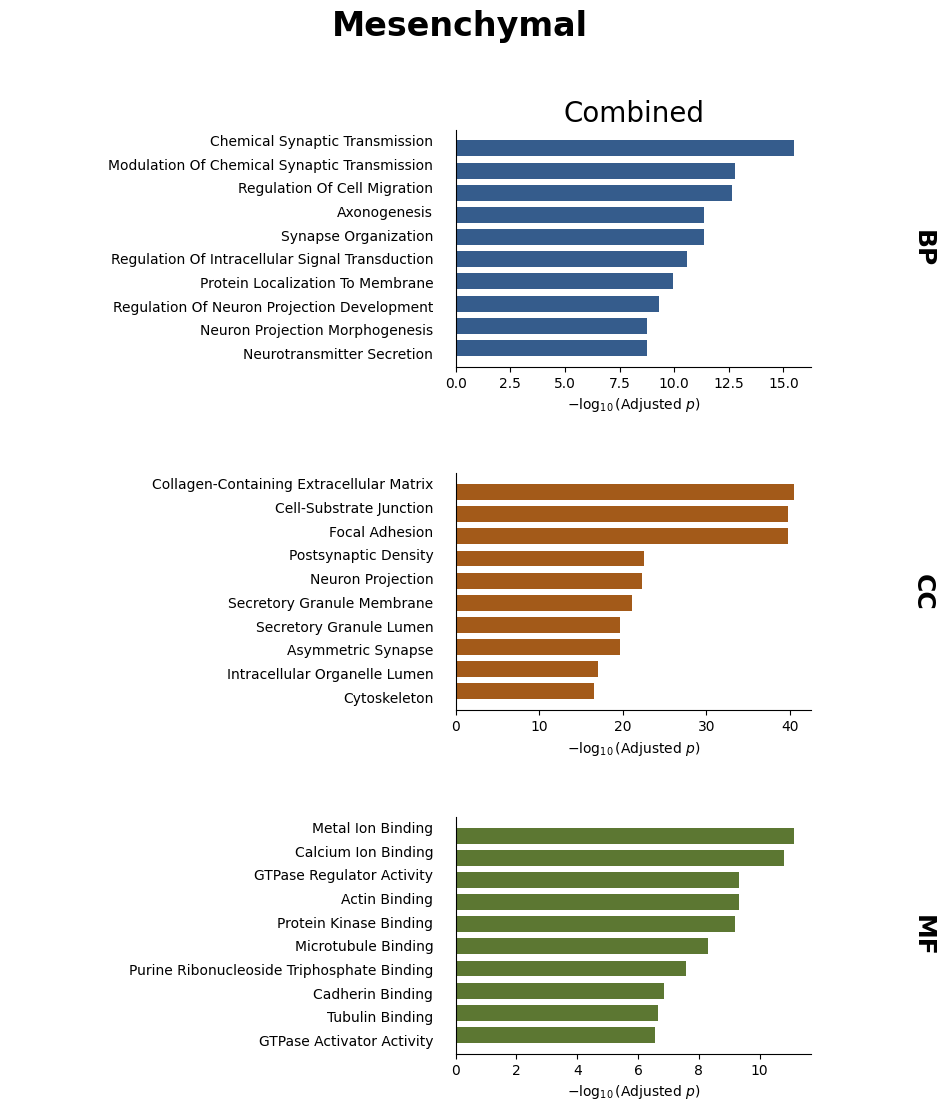

In [20]:
import pandas as pd
shared = []

for subtype, file in files.items():

    df = pd.read_csv(file)

    shared.append(
        set(df["gene_name"].dropna().str.upper())
    )

shared_genes = set.intersection(*shared)


go_shared = {}

for subtype, file in files.items():

    go_shared[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined",
        gene_filter=shared_genes,
        filter_before_significance=True
    )

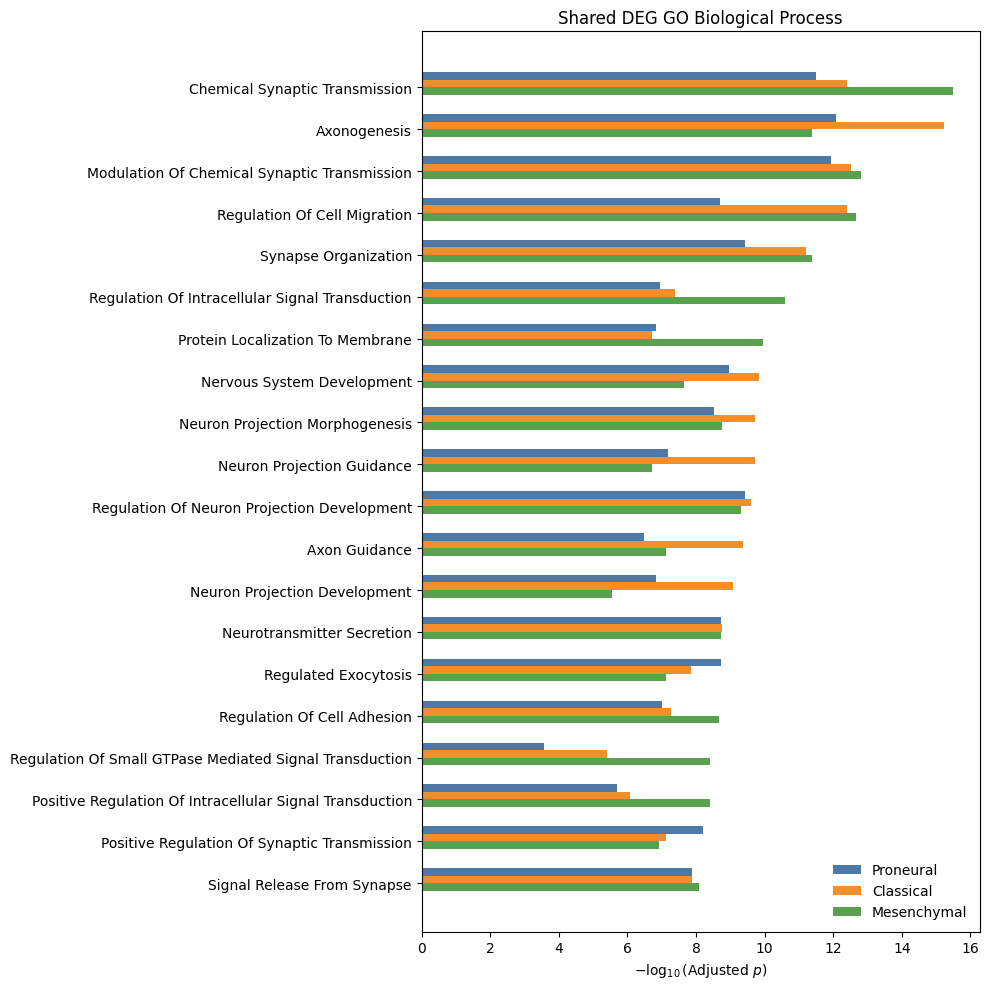

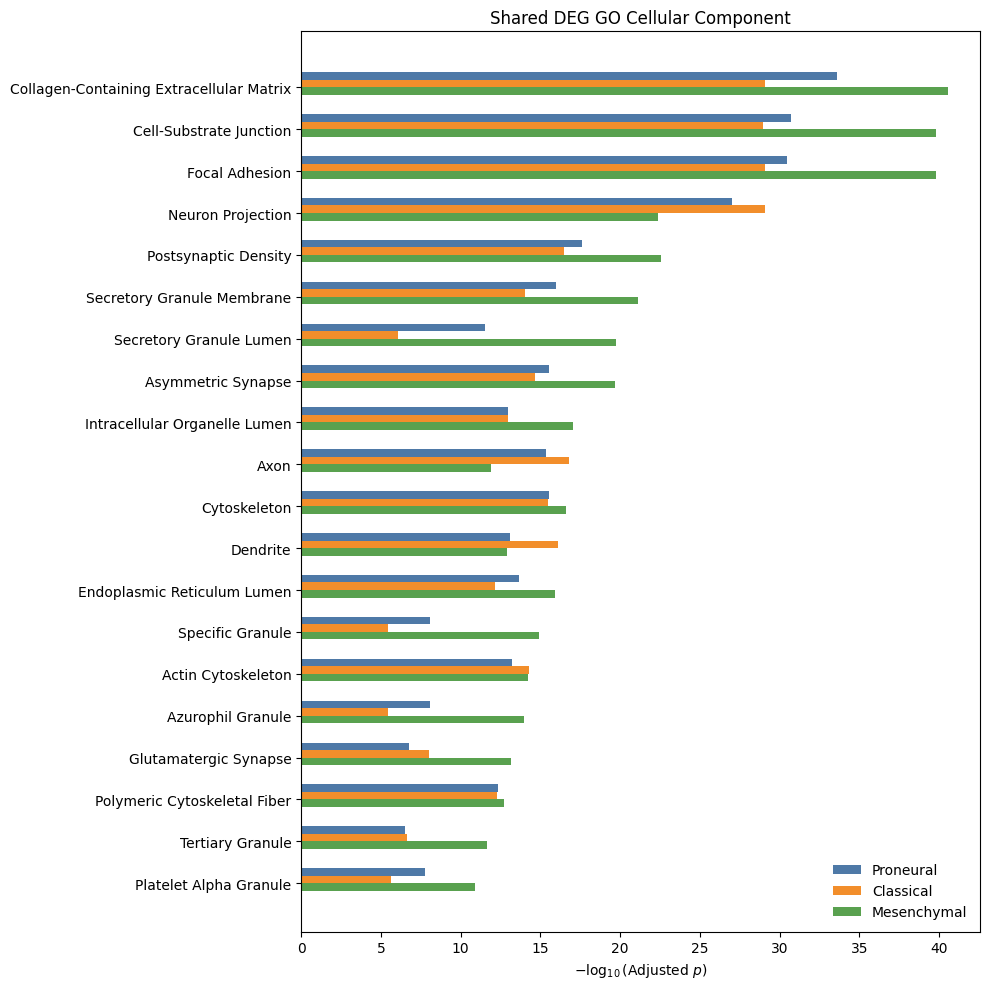

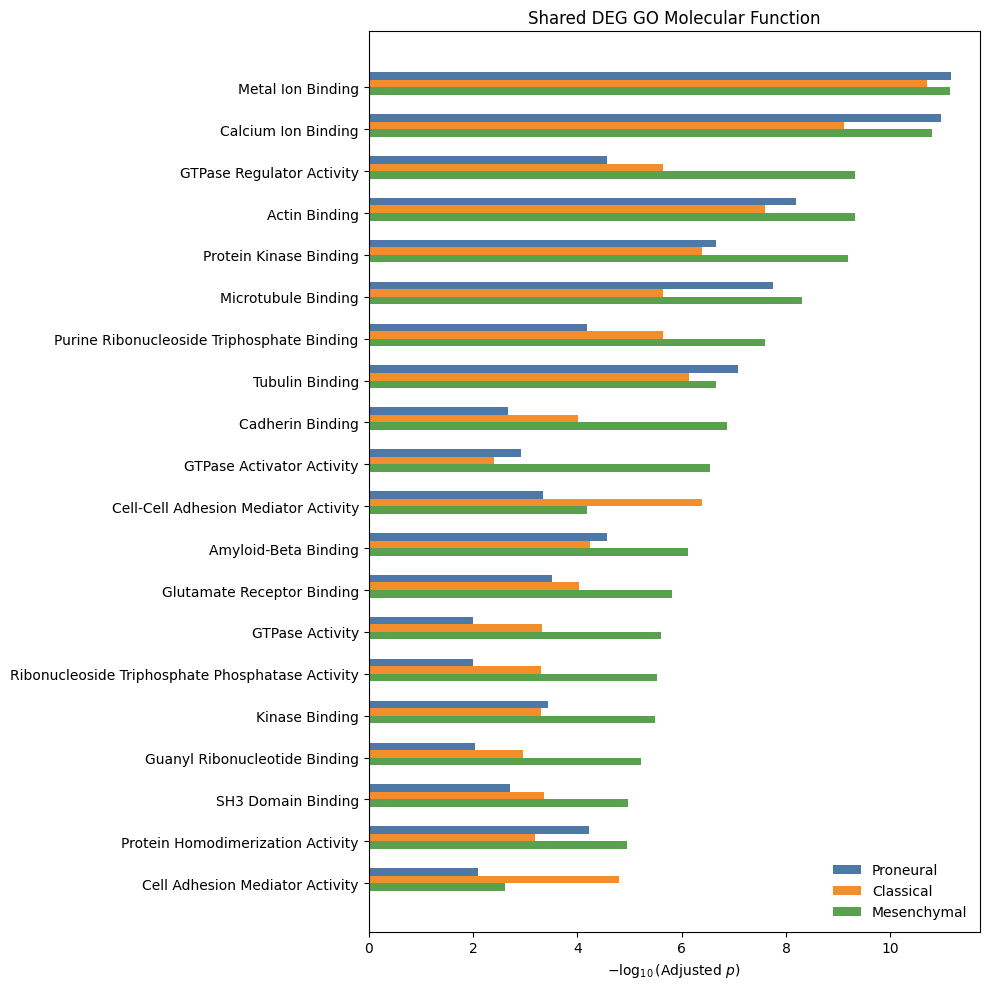

In [7]:
bp = ge.build_go_matrix(
    go_shared,
    ontology="BP",
    min_subtypes=3
)

ge.plot_go_comparison(
    bp,
    "Shared DEG GO Biological Process"
)

cc = ge.build_go_matrix(
    go_shared,
    ontology="CC",
    min_subtypes=3
)

ge.plot_go_comparison(
    cc,
    "Shared DEG GO Cellular Component"
)

mf = ge.build_go_matrix(
    go_shared,
    ontology="MF",
    min_subtypes=3
)

ge.plot_go_comparison(
    mf,
    "Shared DEG GO Molecular Function"
)

Proneural: BP UP
Proneural: BP DOWN
Proneural: CC UP
Proneural: CC DOWN
Proneural: MF UP
Proneural: MF DOWN


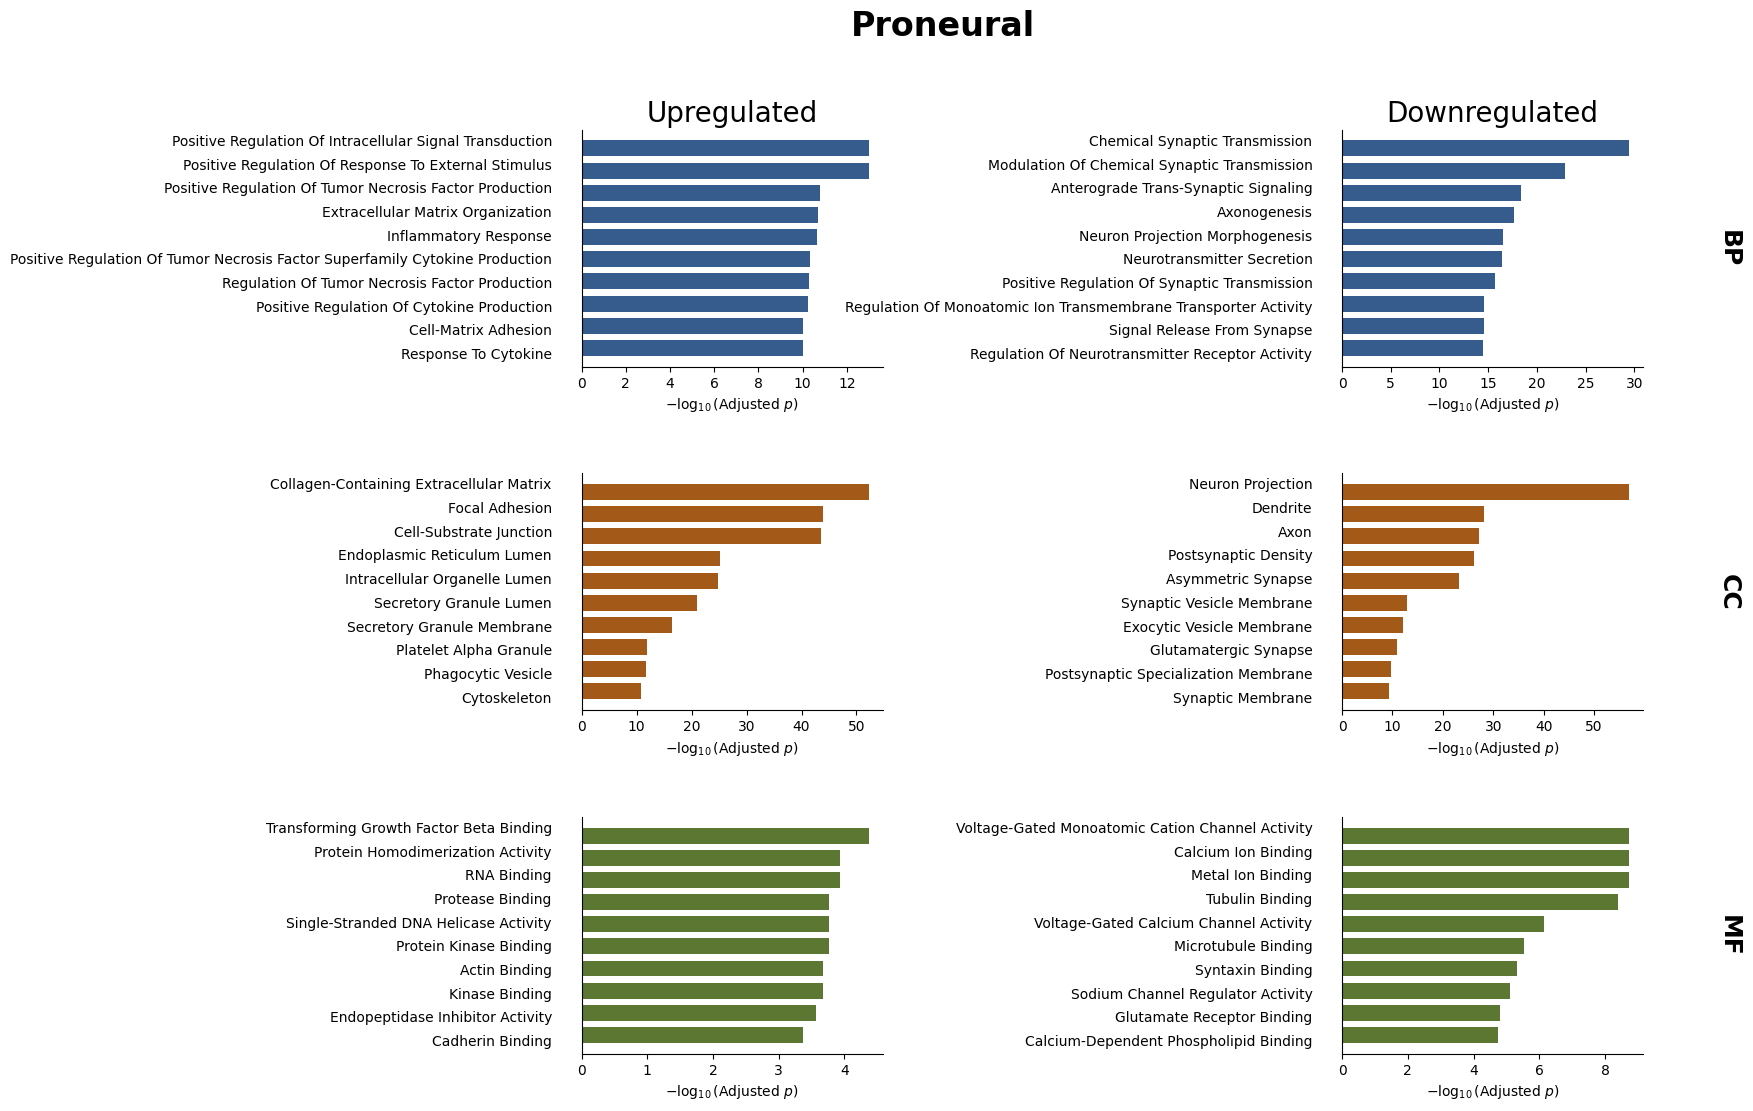

Classical: BP UP
Classical: BP DOWN
Classical: CC UP
Classical: CC DOWN
Classical: MF UP
Classical: MF DOWN


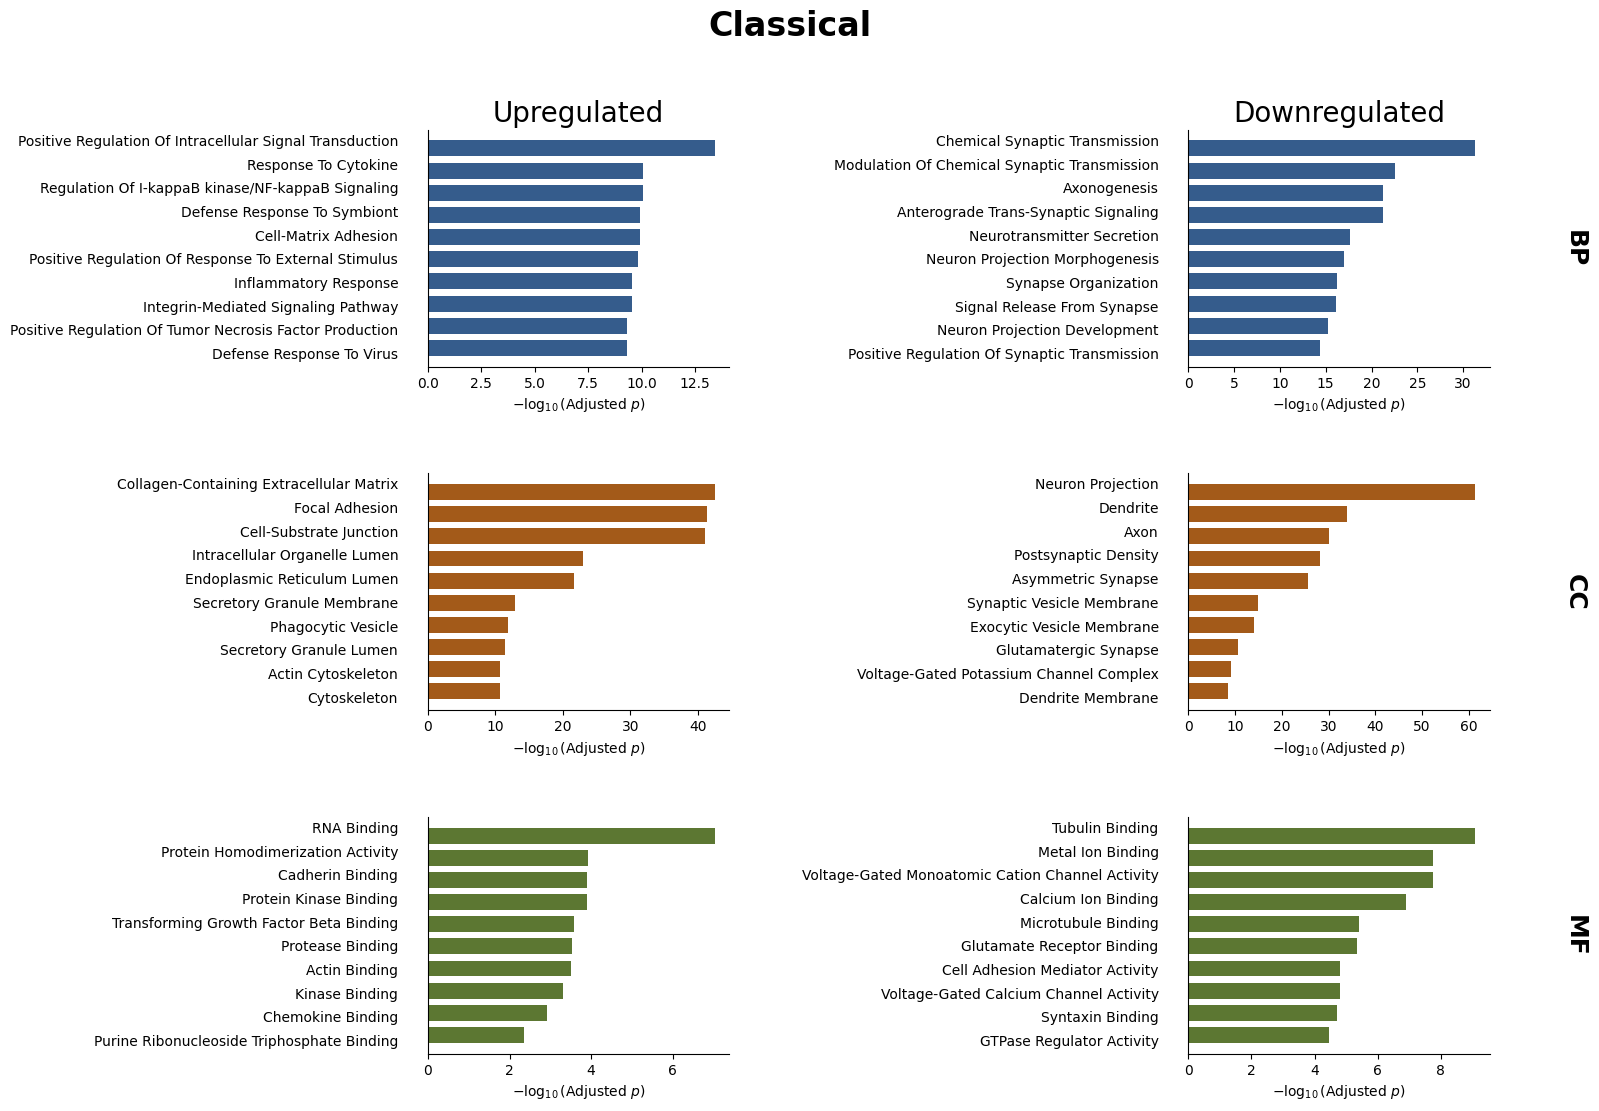

Mesenchymal: BP UP
Mesenchymal: BP DOWN
Mesenchymal: CC UP
Mesenchymal: CC DOWN
Mesenchymal: MF UP
Mesenchymal: MF DOWN


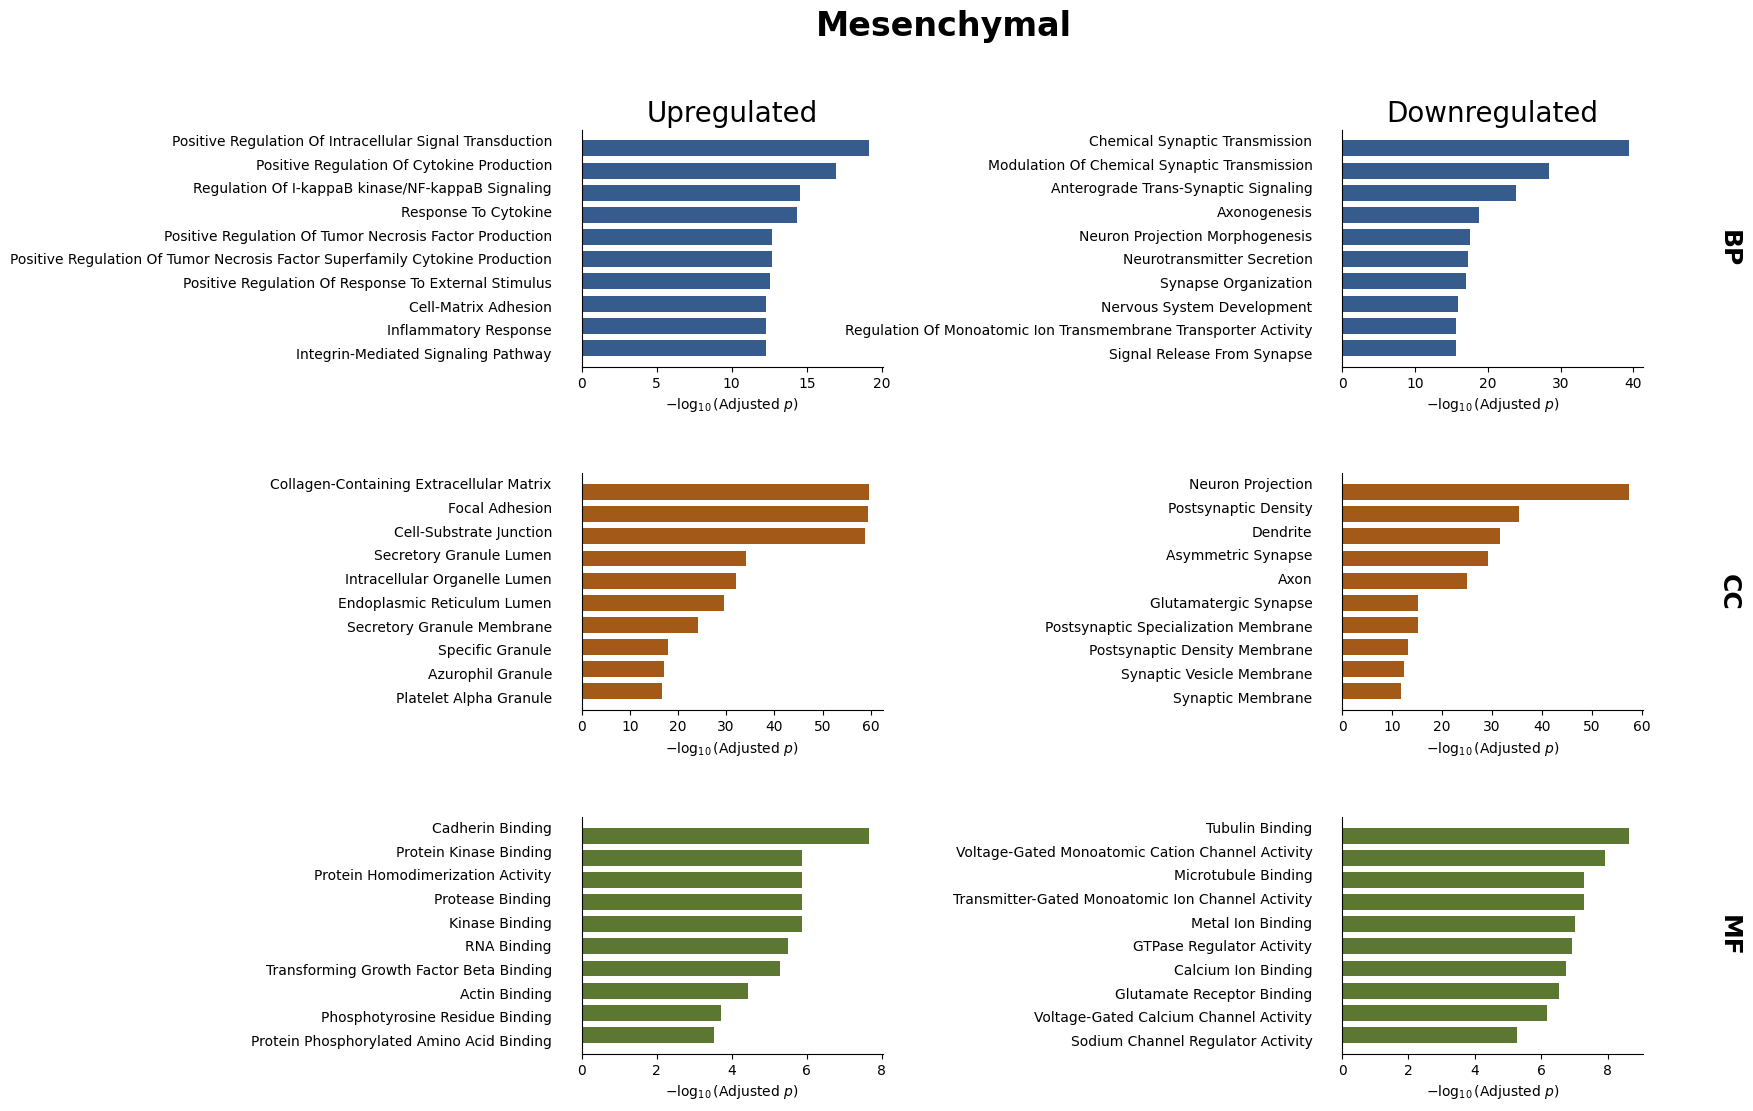

In [ ]:
go_split = {}

for subtype, file in files.items():

    go_split[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="split",
        gene_filter=shared_genes,
        filter_before_significance=True
    )